In [1]:
import os
import analysis_utils as au
import quick_metadata_plots as qmplt
import padeopsIO as pio
import matplotlib.pyplot as plt
import numpy as np
import streamtube

sim_folder =  os.path.join(au.DATA_PATH, "F_0017_X_SU_Files/")

In [2]:
xlim = [-5, 20]
ylim =  [-5, 5]
zlim = 0

In [3]:
%matplotlib inline

In [4]:
run_folder = au.get_run_folder(sim_folder, 5)
sim = pio.BudgetIO(run_folder, padeops = True, runid = 0, normalize_origin="turbine", verbose=False)
print("Existing terms: ", sim.existing_terms())

5
Existing terms:  ['ubar', 'vbar', 'wbar', 'uu', 'uv', 'uw', 'vv', 'vw', 'ww', 'pbar', 'tau11', 'tau12', 'tau13', 'tau22', 'tau23', 'tau33', 'pu', 'pv', 'pw', 'uk', 'vk', 'wk', 'ujtau1j', 'ujtau2j', 'ujtau3j', 'Tbar', 'uT', 'vT', 'wT', 'TT', 'wb']


In [5]:
keylab = pio.budgetkey.key_labels()

def plot_phases(field, sim, phases = [], xlim = [-1, 16], ylim = [-2, 2], zlim = 0, diff = False):
    nphases = len(phases)
    even_phases = nphases % 2 == 0
    extents = []
    xkey = ""
    ykey = ""
    if isinstance(xlim, list):
        extents.append(xlim[0])
        extents.append(xlim[1])
        xkey = "x"
    if isinstance(ylim, list):
        extents.append(ylim[0])
        extents.append(ylim[1])
        if xkey == "":
            xkey = "y"
        else:
            ykey = "y"
    if isinstance(zlim, list):
        extents.append(zlim[0])
        extents.append(zlim[1])
        if ykey == "":
            ykey = "z"
    ds = sim.slice(budget_terms=[field], xlim = xlim, ylim = ylim, zlim = zlim, phase = phases[0])
    nx, ny = ds[field].shape
    vals = np.zeros((nx, ny, nphases))
    vals[:, :, 0] = ds[field]
    for (i, phase) in enumerate(phases):
        if i > 0:
            ds = sim.slice(budget_terms=[field], xlim = xlim, ylim = ylim, zlim = zlim, phase = phase)
            vals[:, :, i] = ds[field]

    if diff:
        for (i, phase) in reversed(list(enumerate(phases))):
            vals[:, :, i] = vals[:, :, i] - vals[:, :, 0]
    vmin = np.min(vals)
    vmax = np.max(vals)

    if even_phases:
        nrows = np.maximum(int(nphases / 2), 1)
    else:
        nrows = np.maximum(int(nphases / 2 + 1), 1)
    fig, axs = plt.subplots(nrows, 2, sharex=True, sharey = True, figsize = (12, 6))
    j, k = 0, 0
    for (i, phase) in enumerate(phases):
        if k > 1:
            j += 1
            k = 0
        im = axs[j, k].imshow(vals[:, :, i].T, extent=extents, vmin = vmin, vmax = vmax, origin='lower')
        axs[j, k].set_xlabel(keylab[xkey])
        axs[j, k].set_ylabel(keylab[ykey])
        axs[j, k].set_title(f"Phase = {phase}")
        k += 1
    if len(phases) % 2 != 0:
        fig.delaxes(axs[j, k])
    fig.tight_layout()
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.04, 0.7])
    fig.colorbar(im, cax=cbar_ax)

    return vals

In [6]:
budget_keys = pio.budgetkey.get_key()
budget_0_keys = []
budget_1_keys = []

for key, (group, _) in budget_keys.items():
    if group == 0:
        budget_0_keys.append(key)
    elif group == 1:
        budget_1_keys.append(key)

In [7]:
sim_folder =  os.path.join(au.DATA_PATH, "F_0018_SU_Files/")
run_folder0 = au.get_run_folder(sim_folder, 0)
sim0 = pio.BudgetIO(run_folder0, padeops = True, runid = 0, normalize_origin="turbine", verbose=False)
run_folder3 = au.get_run_folder(sim_folder, 3)
sim3 = pio.BudgetIO(run_folder3, padeops = True, runid = 0, normalize_origin="turbine", verbose=False)

0
3


In [29]:
sim0.turbineArray.xloc, sim3.turbineArray.xloc

(5.0, 5.0)

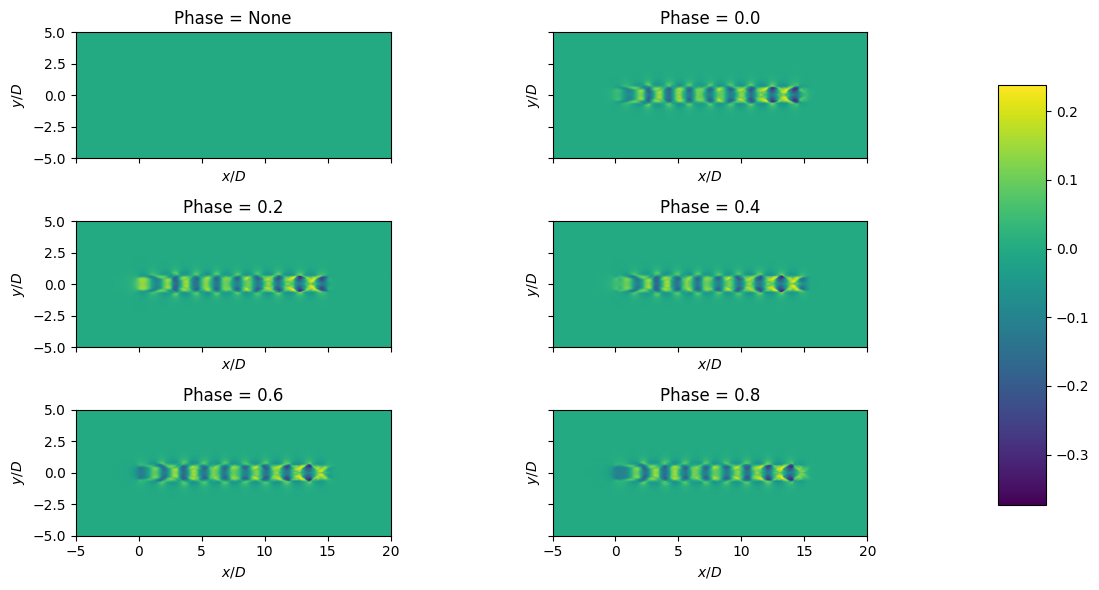

In [8]:
vals = plot_phases('ubar', sim0, [None, 0.0, 0.2, 0.4, 0.6, 0.8], diff = True, xlim = xlim, ylim = ylim, zlim = zlim);

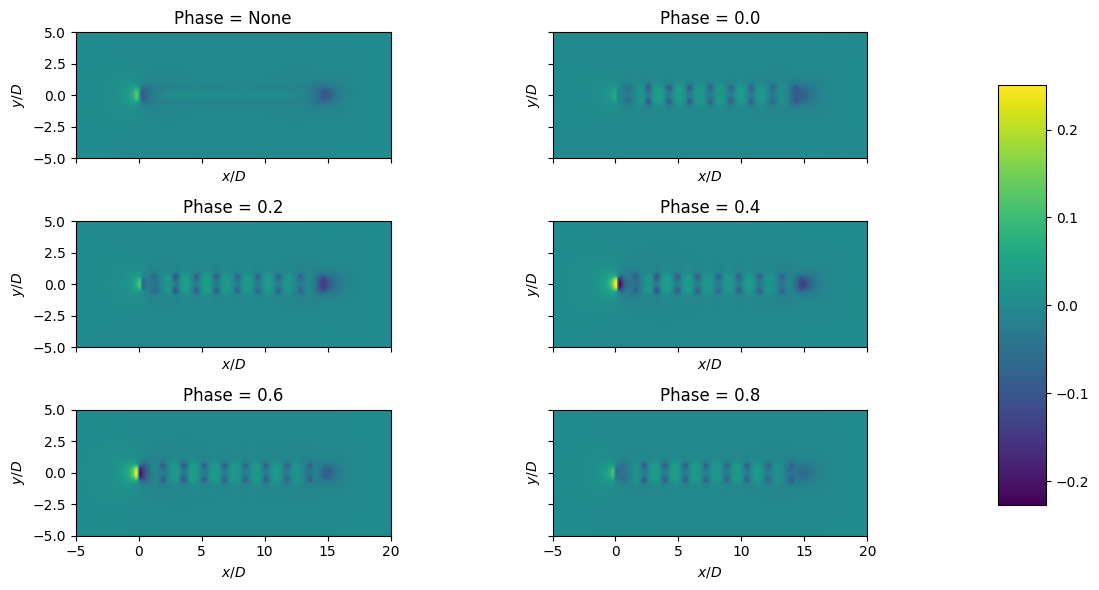

In [9]:
vals = plot_phases('pbar', sim0, [None, 0.0, 0.2, 0.4, 0.6, 0.8], diff = False, xlim = xlim, ylim = ylim, zlim = zlim);

In [10]:
ds0_budget0 = sim0.slice(budget_terms=budget_0_keys, xlim = [-1, 16], ylim = 0, zlim = 0, phase = 0.5)    
ds0_budget1 = sim0.slice(budget_terms=budget_1_keys, xlim = [-1, 16], ylim = 0, zlim = 0, phase = 0.5) 

In [11]:
sim0_log = "/scratch/10264/sgering/Data/F_0018_SU_Files/Sim_0000/phase_budgets_0000.o2522491"
sim3_log = "/scratch/10264/sgering/Data/F_0018_SU_Files/Sim_0003/phase_budgets_0003.o2522496"
sim6_log = "/scratch/10264/sgering/Data/F_0018_SU_Files/Sim_0006/phase_budgets_0006.o2522539"
sim9_log = "/scratch/10264/sgering/Data/F_0018_SU_Files/Sim_0009/phase_budgets_0009.o2522548"

In [12]:
run_folder6 = au.get_run_folder(sim_folder, 6)
sim6 = pio.BudgetIO(run_folder6, padeops = True, runid = 0, normalize_origin="turbine", verbose=False)
run_folder9 = au.get_run_folder(sim_folder, 9)
sim9 = pio.BudgetIO(run_folder9, padeops = True, runid = 0, normalize_origin="turbine", verbose=False)

6
9


In [30]:
sim6.turbineArray.xloc, sim9.turbineArray.xloc

(5.0, 5.0)

In [13]:
def get_log_info(log_file):
    phase_loc_info = pio.query_logfile(log_file, search_terms = ["Current phase", "delta x", "uturb"])
    phases = np.round(phase_loc_info["Current phase"], decimals = 4)
    xloc = phase_loc_info["delta x"]
    uturb = phase_loc_info["uturb"]
    unique_phases = np.sort(np.unique(phases))
    # Compute average delta x for each unique phase
    avg_dx = np.array([xloc[phases == p].mean() for p in unique_phases])
    avg_uturb = np.array([uturb[phases == p].mean() for p in unique_phases])
    return unique_phases, avg_dx, avg_uturb

In [14]:
key_idx = [0, 2, 9]
def plot_sims_diff(sim0, sim1, log0, log1, key_idx):
    fig, axes = plt.subplots(nrows = len(key_idx), ncols = 3, dpi = 300, sharey = "row", sharex = True)
    phases_sim0, dx_sim0, _ = get_log_info(log0)
    phases_sim1, dx_sim1, _ = get_log_info(log1)

    for (i, key) in enumerate([budget_0_keys[idx] for idx in key_idx]):
        ax0, ax1, ax2 = axes[i, 0], axes[i, 1], axes[i, 2]
        xlim = [-3, 3]  
        for phase in [0.1, 0.3, 0.5, 0.7, 0.9, None]:
            dx_idx_0 = np.where(phases_sim0 == phase)[0]
            dx_0 = 0 if len(dx_idx_0) == 0  else dx_sim0[dx_idx_0[0]]

            dx_idx_1 = np.where(phases_sim1 == phase)[0]
            dx_1 = 0 if len(dx_idx_1) == 0  else dx_sim1[dx_idx_1[0]]

            assert np.all(dx_1 == dx_0)
            slice0 = sim0.slice(budget_terms=[key], xlim = xlim, ylim = 0, zlim = 0, phase = phase)
            slice1 = sim1.slice(budget_terms=[key], xlim = xlim, ylim = 0, zlim = 0, phase = phase)
            ax0.plot(np.array(slice0["x"]) - dx_0, slice0[key], label = phase)
            ax0.set_title(key + " tol = 0.01")

            ax1.plot(np.array(slice0["x"]) - dx_1, slice1[key], label = phase)
            ax1.set_title(key + " tol = 0.05")

            ax2.plot(np.array(slice0["x"]) - dx_0, (slice1[key] - slice0[key]), label = phase)
            ax2.set_title(key + " Diff")

    # Get handles and labels from one axis (they’re all the same)
    handles, labels = axes[0, 0].get_legend_handles_labels()
    # Add a single legend to the right of the whole figure
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.02, 0.5))
    # Adjust layout so the legend fits nicely
    fig.tight_layout(rect=[0, 0, 0.88, 1])

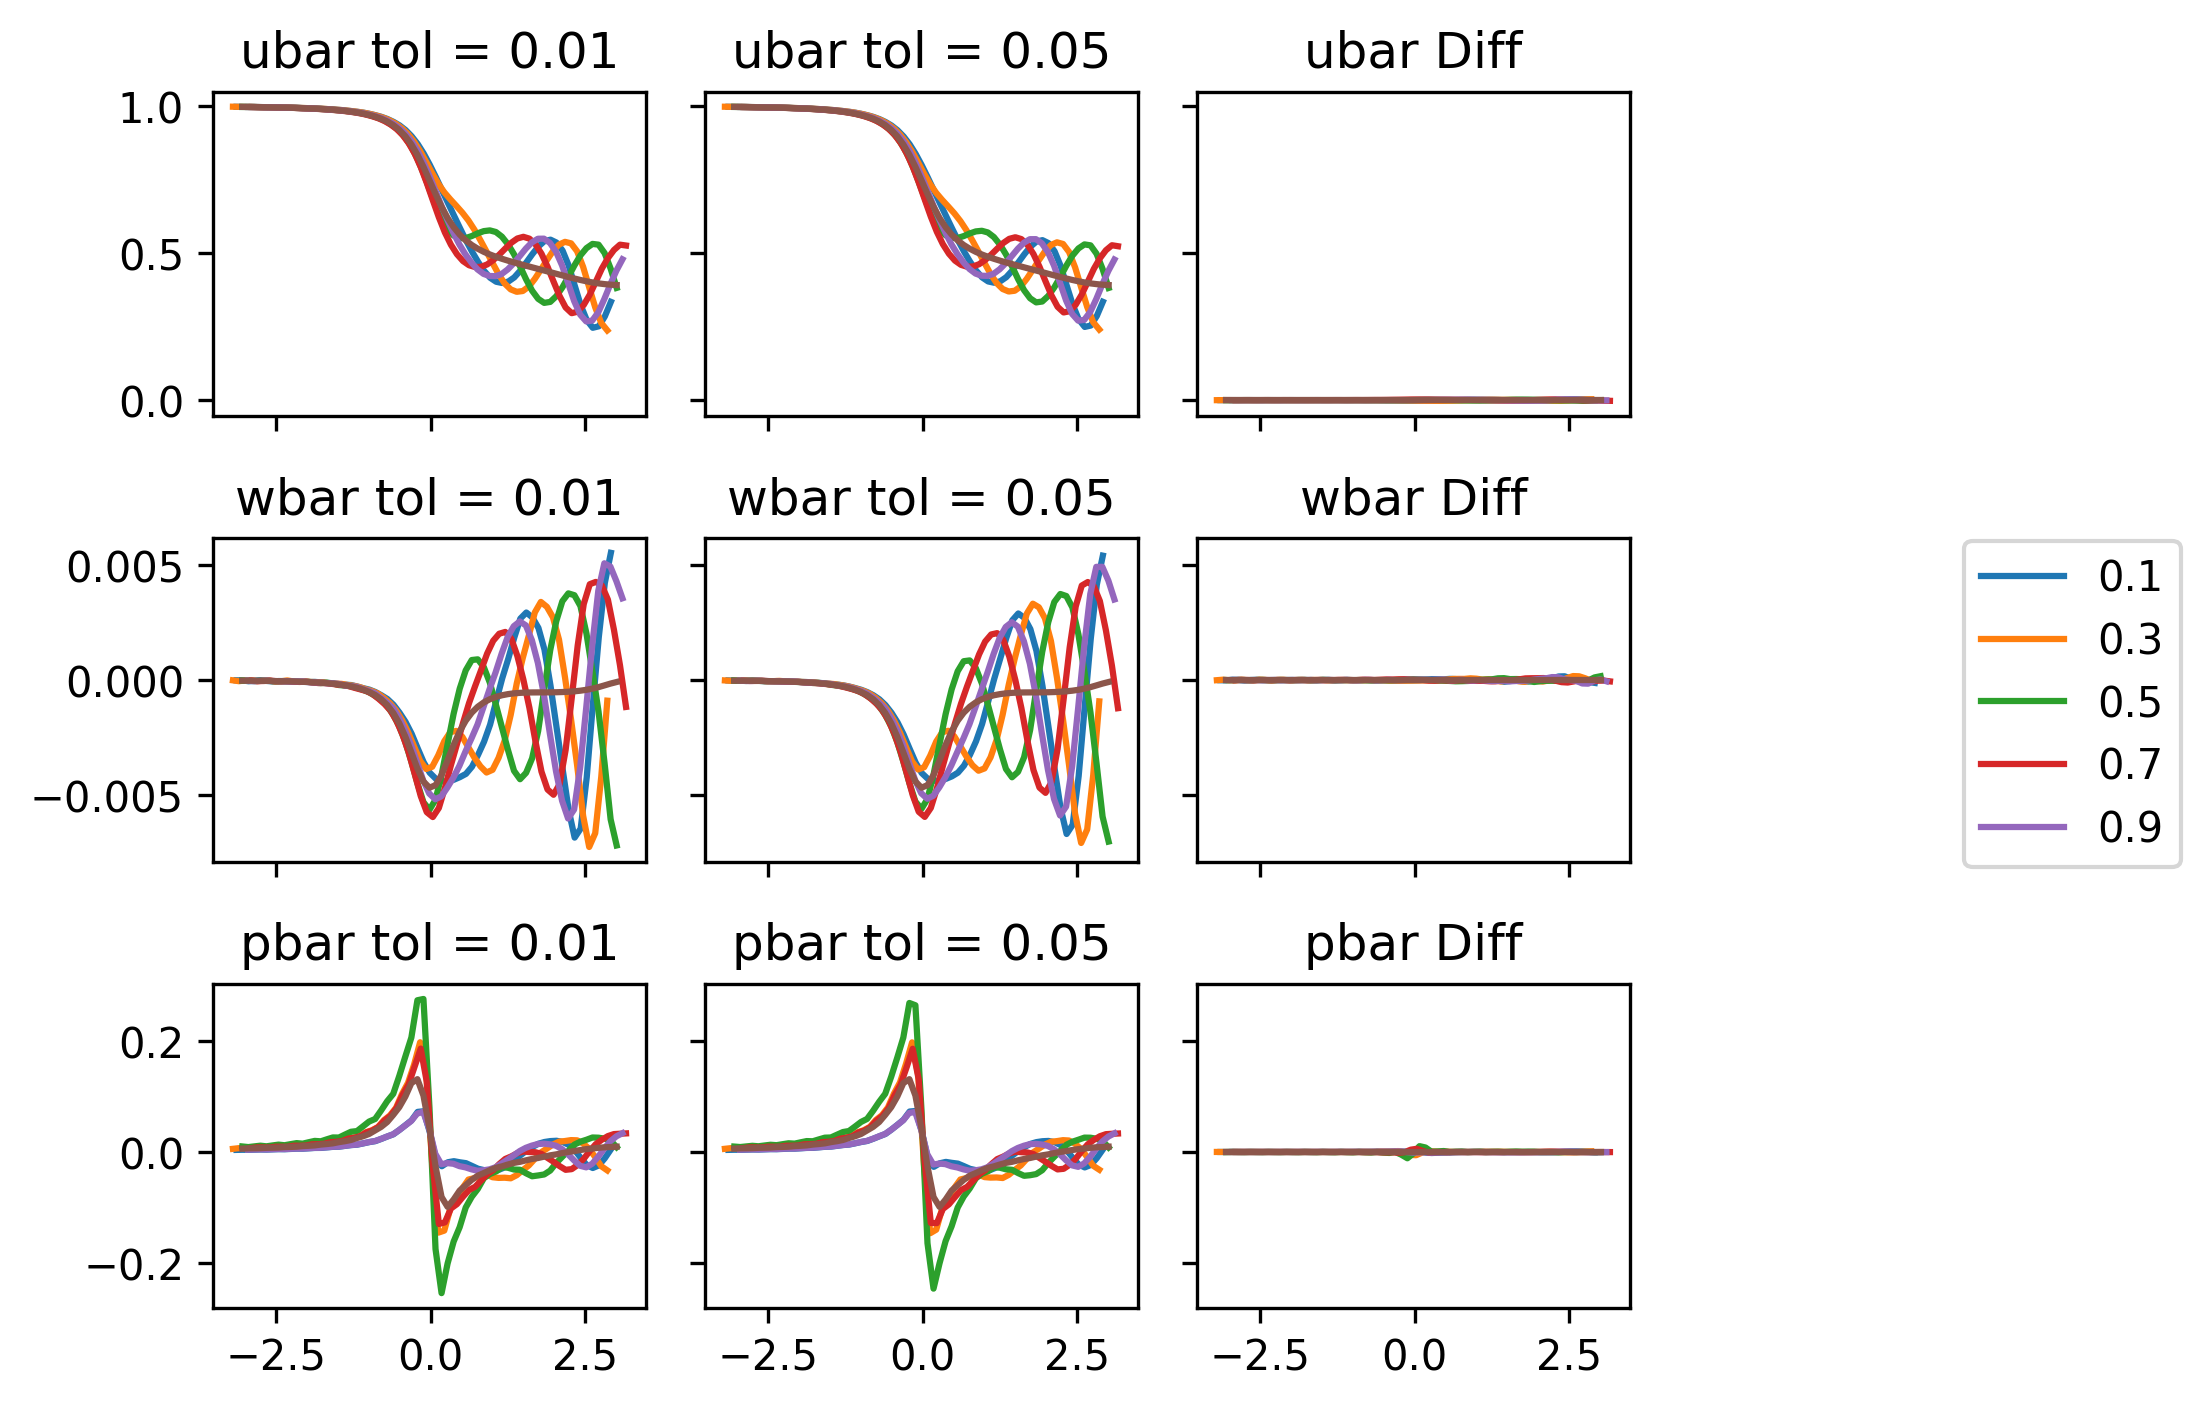

In [15]:
plot_sims_diff(sim0, sim3, sim0_log, sim3_log, key_idx)

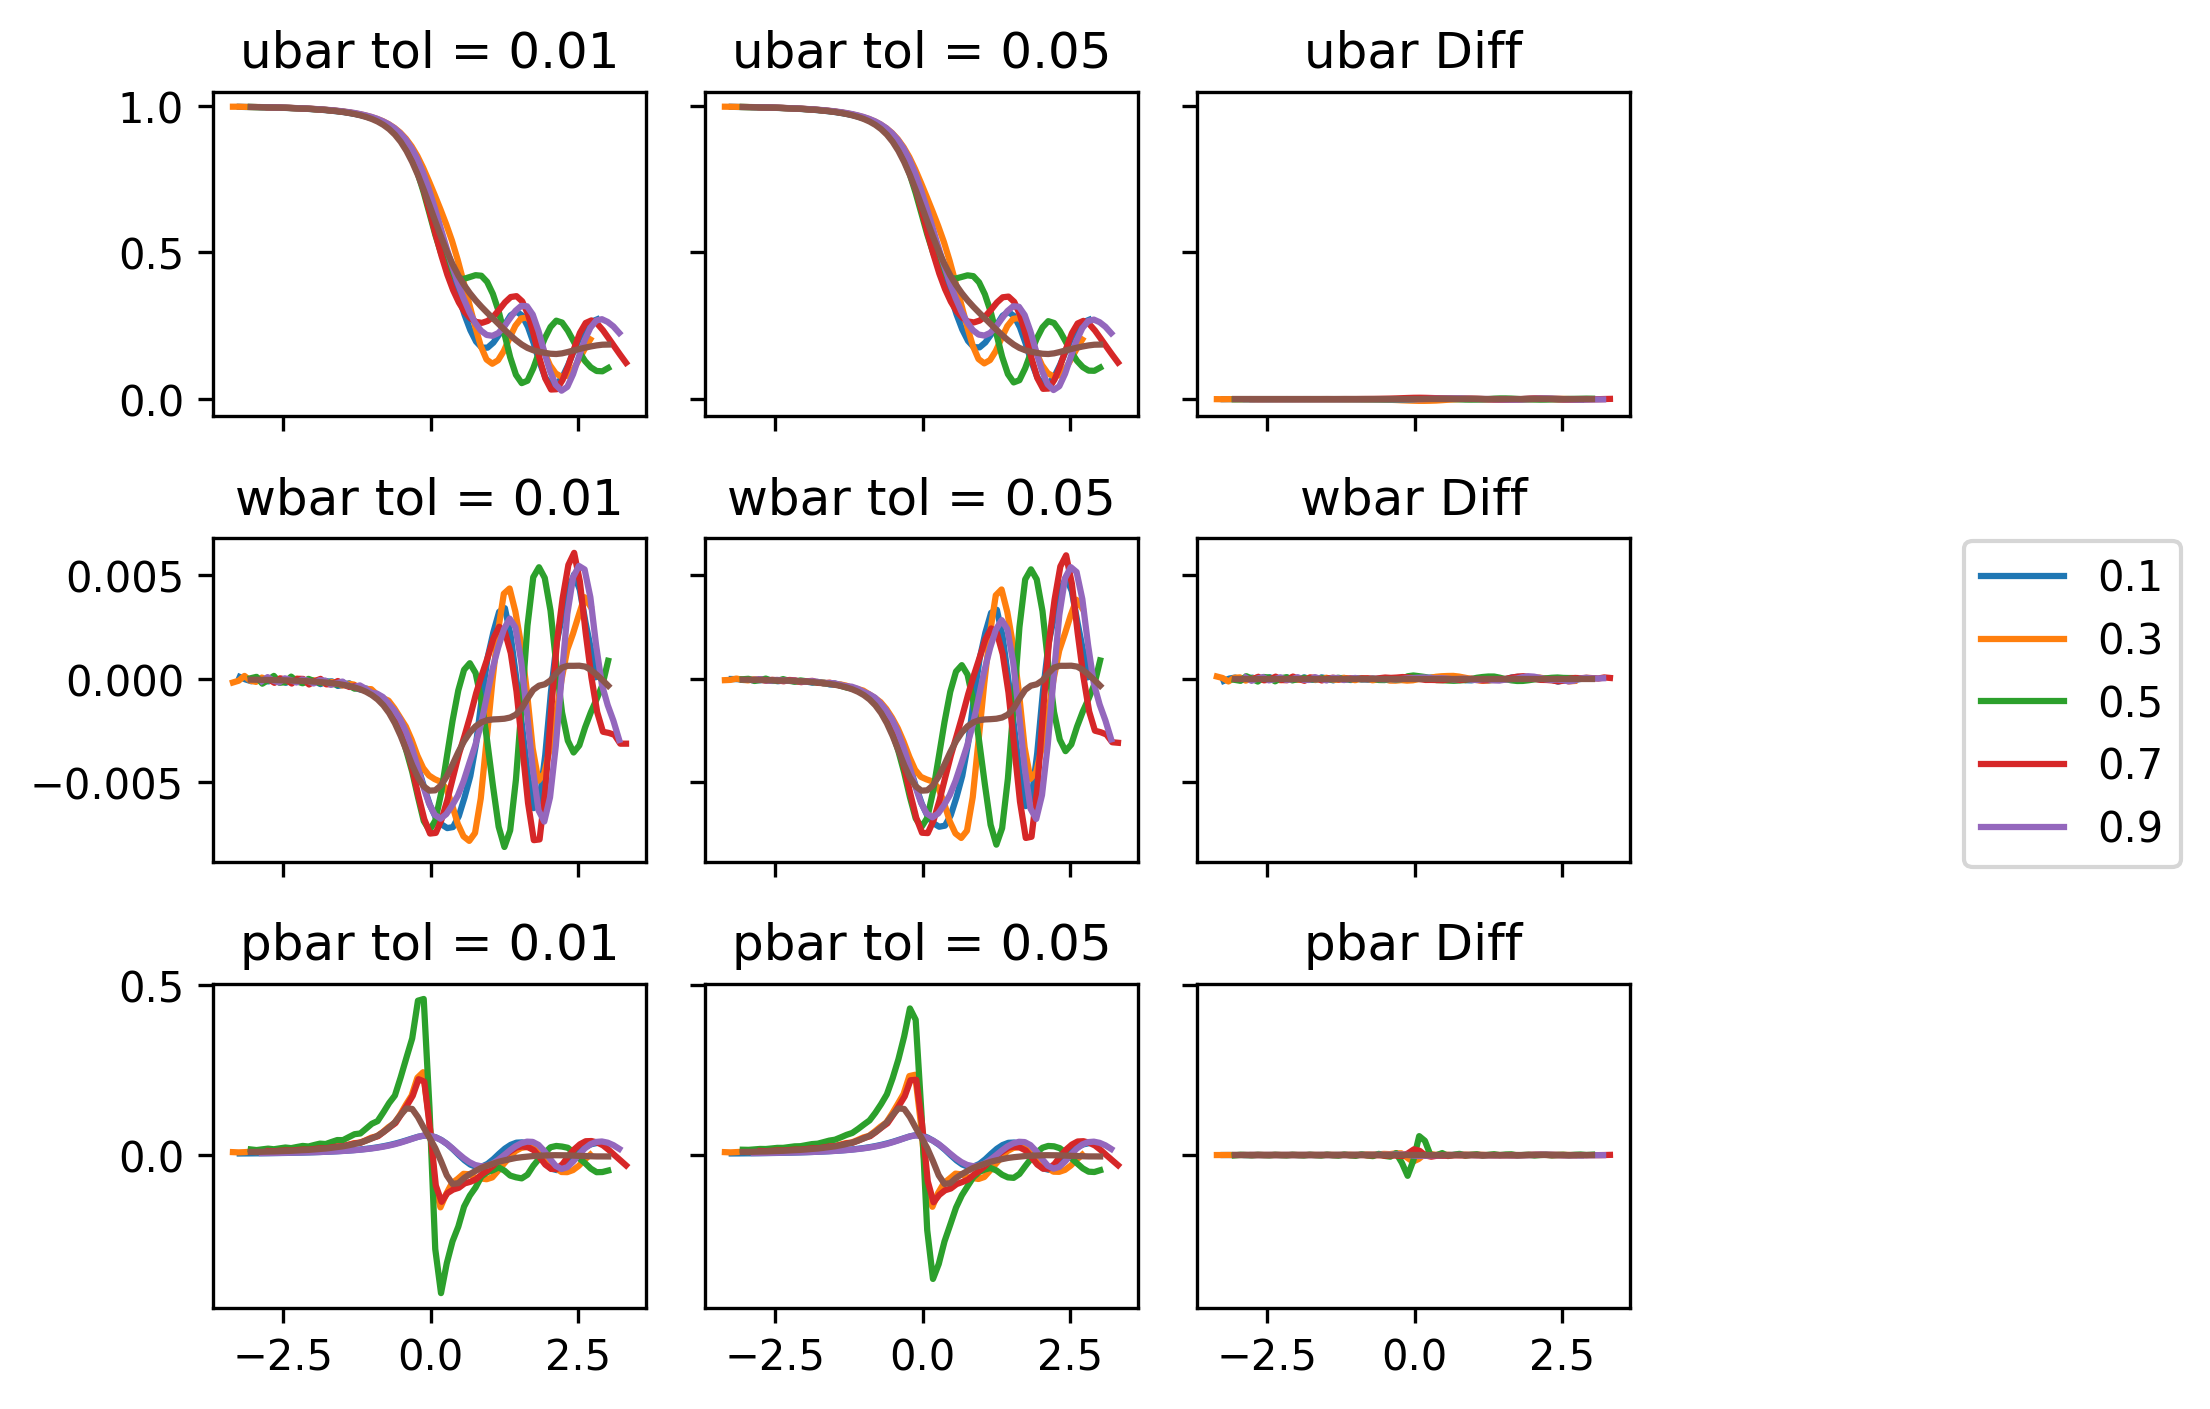

In [16]:
plot_sims_diff(sim6, sim9, sim6_log, sim9_log, key_idx)

In [17]:
def plot_turbine_location_in_tube(sim1, sim_log1, sim2, sim_log2, phases, tol = 0.9, key = "ubar", frame = None):
    # get turbine location
    phases_sim1, dx_sim1, uturb_sim1 = get_log_info(sim_log1)
    phases_sim2, dx_sim2, uturb_sim2 = get_log_info(sim_log2)

    vmin = 0
    vmax = tol
    fig, axes = plt.subplots(nrows = 2, ncols = len(phases), dpi = 300, figsize = (len(phases) * 4, 6))
    for (i, phase) in enumerate(phases):
        (ax1, ax2) = axes[:, i]
        # get turbine position
        idx1 = np.where(phases_sim1 == phase)[0]
        dx1 = 0 if len(idx1) == 0  else dx_sim1[idx1[0]]

        idx2 = np.where(phases_sim2 == phase)[0]
        dx2 = 0 if len(idx2) == 0  else dx_sim2[idx2[0]]

        # get mask
        slice1 = sim1.slice(budget_terms=["ubar", "vbar", "wbar"], xlim = [-2, 16], ylim = [-2, 2], zlim = [-2, 2], phase = phase)
        slice2 = sim2.slice(budget_terms=["ubar", "vbar", "wbar"], xlim = [-2, 16], ylim = [-2, 2], zlim = [-2, 2], phase = phase)

        stream1 = streamtube.Streamtube(slice1["x"], slice1["y"], slice1["z"], slice1["ubar"], slice1["vbar"], slice1["wbar"])
        stream2 = streamtube.Streamtube(slice2["x"], slice2["y"], slice2["z"], slice2["ubar"], slice2["vbar"], slice2["wbar"])

        mask1 = stream1.compute_mask(return_mask=True)
        mask2 = stream2.compute_mask(return_mask=True)

        xlim = [-2, 2]
        ylim = [-2, 2]
        ds1 = sim1.slice(budget_terms=[key], xlim = xlim, ylim = ylim, zlim = 0, phase = phase)
        ds2 = sim2.slice(budget_terms=[key], xlim = xlim, ylim = ylim, zlim = 0, phase = phase)
        
        zidx1 = np.argmin(np.abs(slice1["z"].values))
        zidx2 = np.argmin(np.abs(slice2["z"].values))
        vals1 = np.multiply(ds1[key], mask1[0:len(ds1["x"]), :, zidx1])
        vals1 = np.where(vals1 > tol, 0.0, vals1)
        vals2 = np.multiply(ds2[key], mask2[0:len(ds2["x"]), :, zidx2])
        vals2 = np.where(vals2 > tol, 0.0, vals2)

        y_idx1 = np.argmax(vals1[:, int(len(ds1["y"]) / 2)] != 0)
        vals1[0:y_idx1, :] = 0.0

        y_idx2 = np.argmax(vals2[:, int(len(ds2["y"]) / 2)] != 0)
        vals2[0:y_idx2, :] = 0.0

        vals1 = np.where(vals1 == 0, np.nan, vals1)
        vals2 = np.where(vals2 == 0, np.nan, vals1)

        if frame == "turbine":
            uturb1 = 0 if len(idx1) == 0  else uturb_sim1[idx1[0]]
            uturb2 = 0 if len(idx2) == 0  else uturb_sim2[idx2[0]]
            vals1 = vals1 - uturb1
            vals2 = vals2 - uturb2
            vmin = -0.2
            vmax = 1.6

        ax1.axvline(x=dx1, linestyle = "--", c = "lightgrey")
        ax1.imshow(vals1.T, origin='lower', extent = (xlim[0], xlim[1], ylim[0], ylim[1]), vmin = vmin, vmax = vmax)
        ax1.scatter([dx1], [0])

        ax2.axvline(x=dx2, linestyle = "--", c = "lightgrey")
        im = ax2.imshow(vals2.T, origin='lower', extent = (xlim[0], xlim[1], ylim[0], ylim[1]), vmin = vmin, vmax = vmax)
        ax2.scatter([dx2], [0])

        y_idx = int(len(vals1[0, :]) / 2)
        x_idx1 = int(np.abs(ds1["x"] - dx1).argmin().item())
        x_idx2 = int(np.abs(ds2["x"] - dx2).argmin().item())
        ax1.set_title(f"Phase: {phase}, dx = {round(dx1, ndigits = 2)}, u = {round(vals1[x_idx1, y_idx], ndigits = 2)}")
        ax2.set_title(f"Phase: {phase}, dx = {round(dx2, ndigits = 2)}, u = {round(vals2[x_idx2, y_idx], ndigits = 2)}")

    cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.046, pad=0.05)
    cbar.set_label(r"$\overline{u}/U$", rotation=90, labelpad=15)


In [18]:
f = 0.4
A1, A2 = 0.4, 0.8
A1 / (f * 2 * np.pi), A2 / (f * 2 * np.pi)

(0.15915494309189535, 0.3183098861837907)

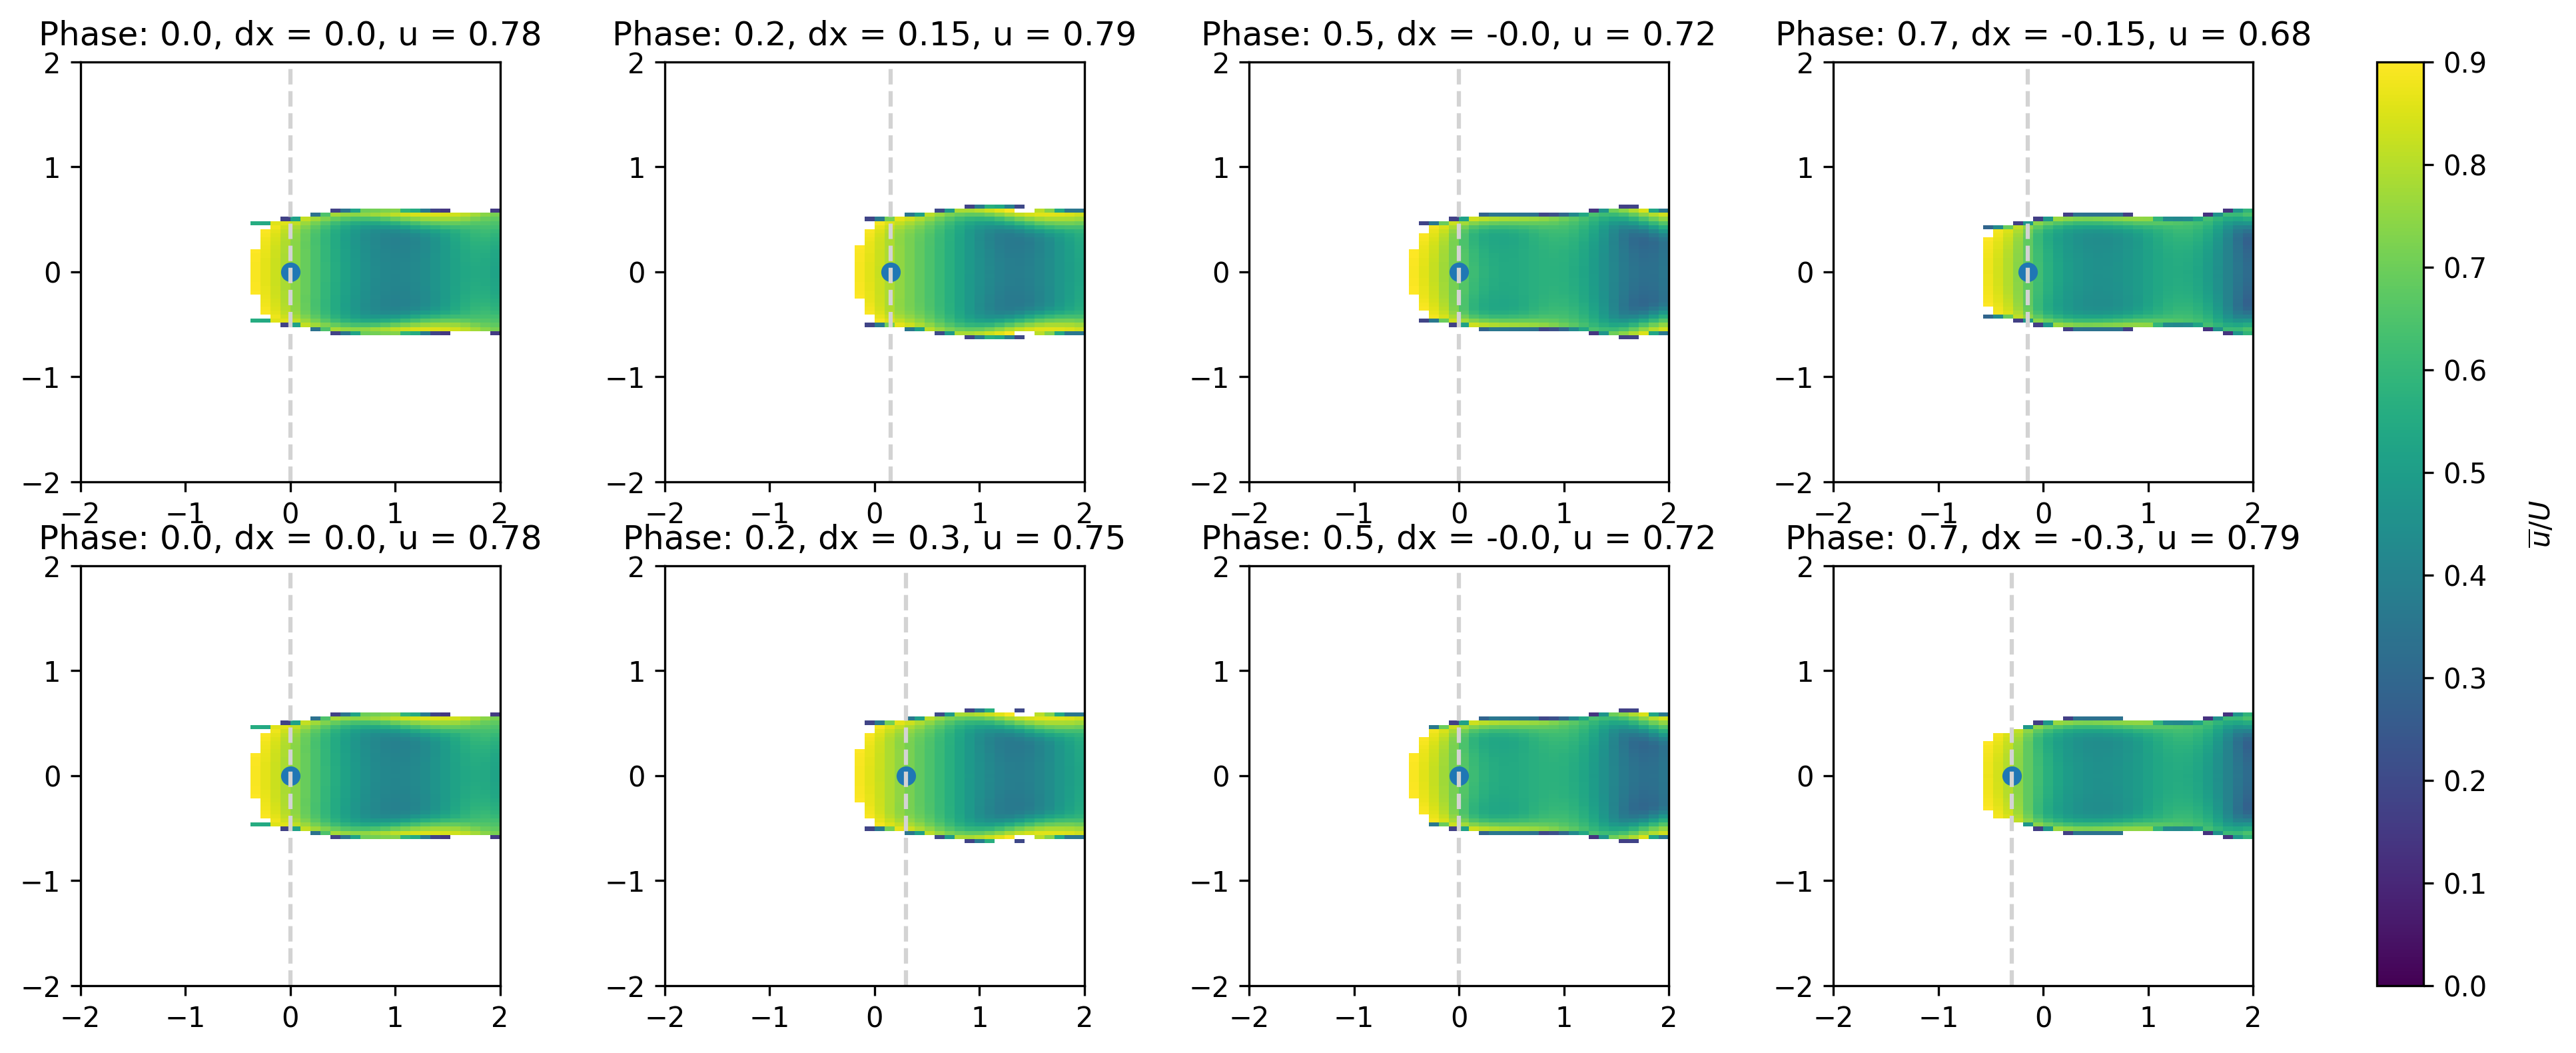

In [32]:
plot_turbine_location_in_tube(sim3, sim3_log, sim9, sim9_log, [0.0, 0.2, 0.5, 0.7], tol = 0.9)

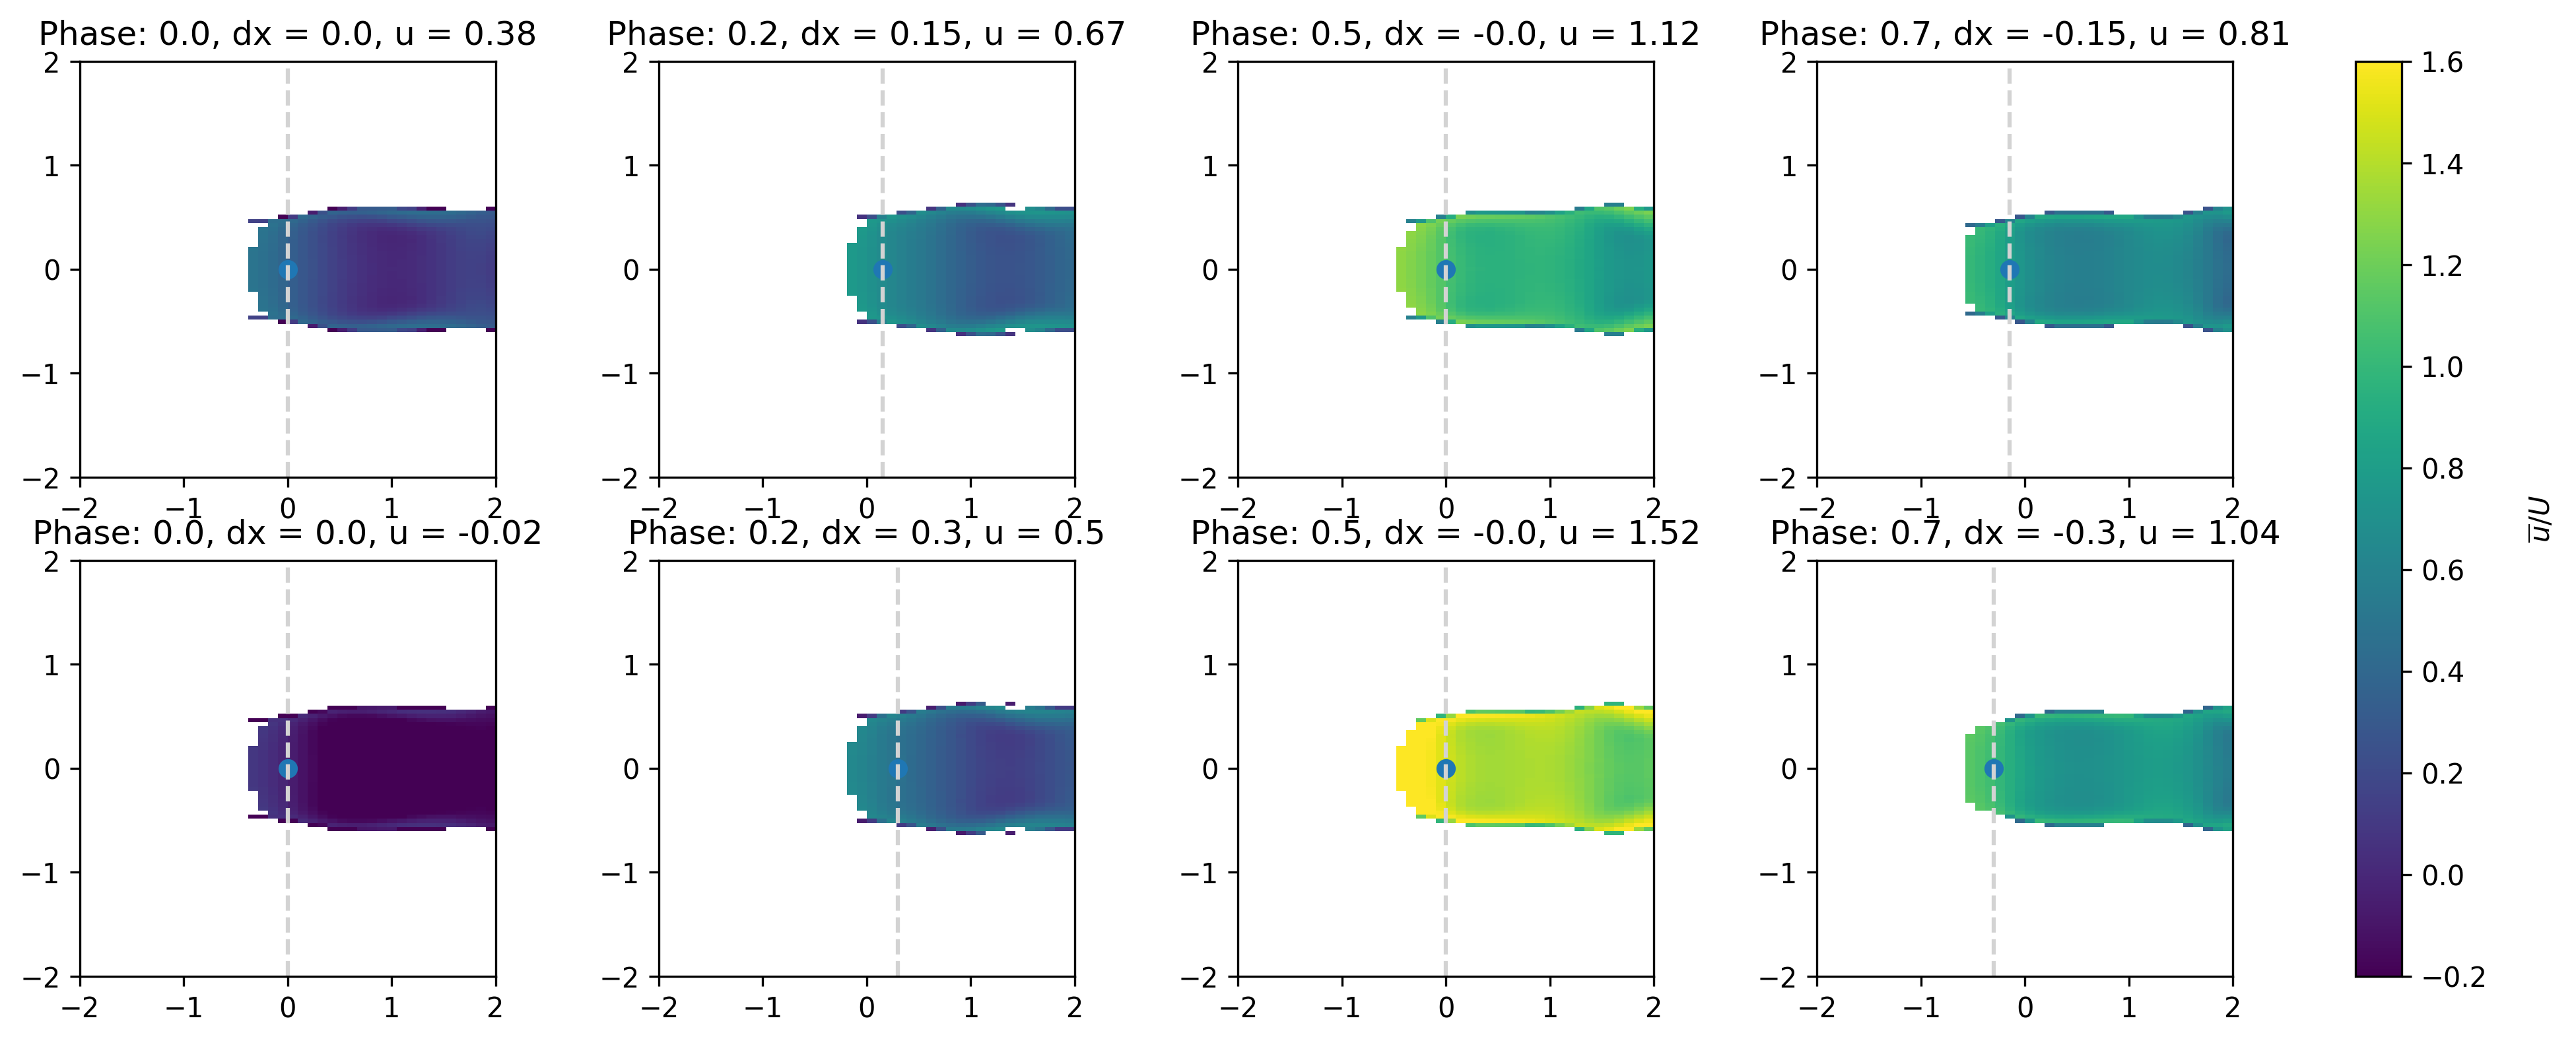

In [33]:
plot_turbine_location_in_tube(sim3, sim3_log, sim9, sim9_log, [0.0, 0.2, 0.5, 0.7], tol = 0.9, frame = "turbine")